# **Section A: Data Cleaning**

In [38]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import os
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [4]:
#Load data
adoption_data = pd.read_csv('C:\\Users\\alyss\\OneDrive\\Springboard Data Science Bootcamp\\Capstone 2\\Springboard Capstone 2 Adoption Prediction Model\\pet_adoption_data.csv')
print(adoption_data.head())

   PetID PetType             Breed  AgeMonths   Color    Size   WeightKg  \
0    500    Bird          Parakeet        131  Orange   Large   5.039768   
1    501  Rabbit            Rabbit         73   White   Large  16.086727   
2    502     Dog  Golden Retriever        136  Orange  Medium   2.076286   
3    503    Bird          Parakeet         97   White   Small   3.339423   
4    504  Rabbit            Rabbit        123    Gray   Large  20.498100   

   Vaccinated  HealthCondition  TimeInShelterDays  AdoptionFee  PreviousOwner  \
0           1                0                 27          140              0   
1           0                0                  8          235              0   
2           0                0                 85          385              0   
3           0                0                 61          217              1   
4           0                0                 28           14              1   

   AdoptionLikelihood  
0                   0  
1       

In [3]:
#Explore the data - column types
adoption_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2007 entries, 0 to 2006
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PetID               2007 non-null   int64  
 1   PetType             2007 non-null   object 
 2   Breed               2007 non-null   object 
 3   AgeMonths           2007 non-null   int64  
 4   Color               2007 non-null   object 
 5   Size                2007 non-null   object 
 6   WeightKg            2007 non-null   float64
 7   Vaccinated          2007 non-null   int64  
 8   HealthCondition     2007 non-null   int64  
 9   TimeInShelterDays   2007 non-null   int64  
 10  AdoptionFee         2007 non-null   int64  
 11  PreviousOwner       2007 non-null   int64  
 12  AdoptionLikelihood  2007 non-null   int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 204.0+ KB


In [4]:
# Convert generic object columns to sensible categorical data types
categorical_cols = ['PetType', 'Breed', 'Color', 'Size']
for col in categorical_cols:
    adoption_data[col] = adoption_data[col].astype('category')

# Print updated data types to verify
print(adoption_data.dtypes)

PetID                    int64
PetType               category
Breed                 category
AgeMonths                int64
Color                 category
Size                  category
WeightKg               float64
Vaccinated               int64
HealthCondition          int64
TimeInShelterDays        int64
AdoptionFee              int64
PreviousOwner            int64
AdoptionLikelihood       int64
dtype: object


In [5]:
#Explore the data - summary stats
adoption_data.describe()

,PetID,AgeMonths,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood
count,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000
mean,1503.000000,92.279522,15.705776,0.701046,0.196313,43.974091,249.142003,0.301943,0.328351
std,579.515315,52.148363,8.327749,0.457914,0.397307,25.740253,142.887040,0.459215,0.469730
min,500.000000,1.000000,1.018198,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1001.500000,48.000000,8.730396,0.000000,0.000000,21.000000,127.000000,0.000000,0.000000
50%,1503.000000,94.000000,15.925416,1.000000,0.000000,45.000000,242.000000,0.000000,0.000000
75%,2004.500000,138.000000,22.737180,1.000000,0.000000,66.000000,375.000000,1.000000,1.000000
max,2506.000000,179.000000,29.995628,1.000000,1.000000,89.000000,499.000000,1.000000,1.000000


In [6]:
#Unique values
unique = adoption_data.nunique()
print(unique)

PetID                 2007
PetType                  4
Breed                    7
AgeMonths              179
Color                    5
Size                     3
WeightKg              2007
Vaccinated               2
HealthCondition          2
TimeInShelterDays       89
AdoptionFee            493
PreviousOwner            2
AdoptionLikelihood       2
dtype: int64


In [7]:
#Unique value frequencies
unique_freq = adoption_data.value_counts()
print(unique_freq)

PetID  PetType  Breed     AgeMonths  Color   Size    WeightKg   Vaccinated  HealthCondition  TimeInShelterDays  AdoptionFee  PreviousOwner  AdoptionLikelihood
500    Bird     Parakeet  131        Orange  Large   5.039768   1           0                27                 140          0              0                     1
1834   Rabbit   Rabbit    36         Black   Large   26.977993  1           1                86                 386          1              0                     1
1847   Cat      Siamese   35         Black   Small   12.669413  1           0                15                 165          0              0                     1
1846   Rabbit   Rabbit    164        Black   Small   14.920537  1           0                44                 181          0              0                     1
1845   Bird     Parakeet  1          Orange  Medium  21.703127  1           1                25                 279          0              1                     1
                     

In [8]:
#Calculate percent of unique values for each feature
total_rows = len(adoption_data)
percent_unique = (adoption_data.nunique() / total_rows) * 100
print("\nPercentage of Unique Values per Column:")
print(percent_unique)


Percentage of Unique Values per Column:
PetID                 100.000000
PetType                 0.199302
Breed                   0.348779
AgeMonths               8.918784
Color                   0.249128
Size                    0.149477
WeightKg              100.000000
Vaccinated              0.099651
HealthCondition         0.099651
TimeInShelterDays       4.434479
AdoptionFee            24.564026
PreviousOwner           0.099651
AdoptionLikelihood      0.099651
dtype: float64


In [9]:
#Missing values (all counts are 2007, indicating no missing values, but for the sake of completeness:)
missing = adoption_data.isna().sum()
print(missing)

PetID                 0
PetType               0
Breed                 0
AgeMonths             0
Color                 0
Size                  0
WeightKg              0
Vaccinated            0
HealthCondition       0
TimeInShelterDays     0
AdoptionFee           0
PreviousOwner         0
AdoptionLikelihood    0
dtype: int64


In [10]:
#Duplicate values
dupe = adoption_data.duplicated()
print(dupe)

print(adoption_data[adoption_data.duplicated()])

0       False
1       False
2       False
3       False
4       False
        ...  
2002    False
2003    False
2004    False
2005    False
2006    False
Length: 2007, dtype: bool
Empty DataFrame
Columns: [PetID, PetType, Breed, AgeMonths, Color, Size, WeightKg, Vaccinated, HealthCondition, TimeInShelterDays, AdoptionFee, PreviousOwner, AdoptionLikelihood]
Index: []


***Observations***  

**Age:** Ages range from 1 month to 179 months. 179 months is about 15 years, which is plausible for a senior dog. It's possible the shelter doesn't adopt out animals less than 1 month old. It's also possible that that is the floor of the data and all animals 1 month or younger are labeled as 1 month old. This is a possible limitation of the data.  

**Weight:** The minimum weight is 1.01 kg, and the maximum is 29.99 kg. For a dataset containing birds, rabbits, cats, and dogs, this wide spread is plausible. I will likely want to group or scale these later during feature engineering.

**LOS:** The max time in shelter is 89 days. This could be accurate, or it could represent a cutoff for the beginning of a new quarter, where LOS calculations are often reset. This is a possible limitation of the data.  

**Target Imbalance:** The mean of `AdoptionLikelihood` is 0.328, which tells us that roughly 33% of the entries resulted in adoptions, meaning our target classes are slightly imbalanced but highly workable for classification modeling.

# **Section B: EDA**

## Hypotheses to explore  

- **Hypothesis 1:** Younger animals (AgeMonths) exhibit significantly higher adoption rates across all species groups.
- **Hypothesis 2:** Lower adoption fees (AdoptionFee) and shorter stay durations (TimeInShelterDays) directly correlate with positive adoption indicators.

<Figure size 1000x400 with 0 Axes>

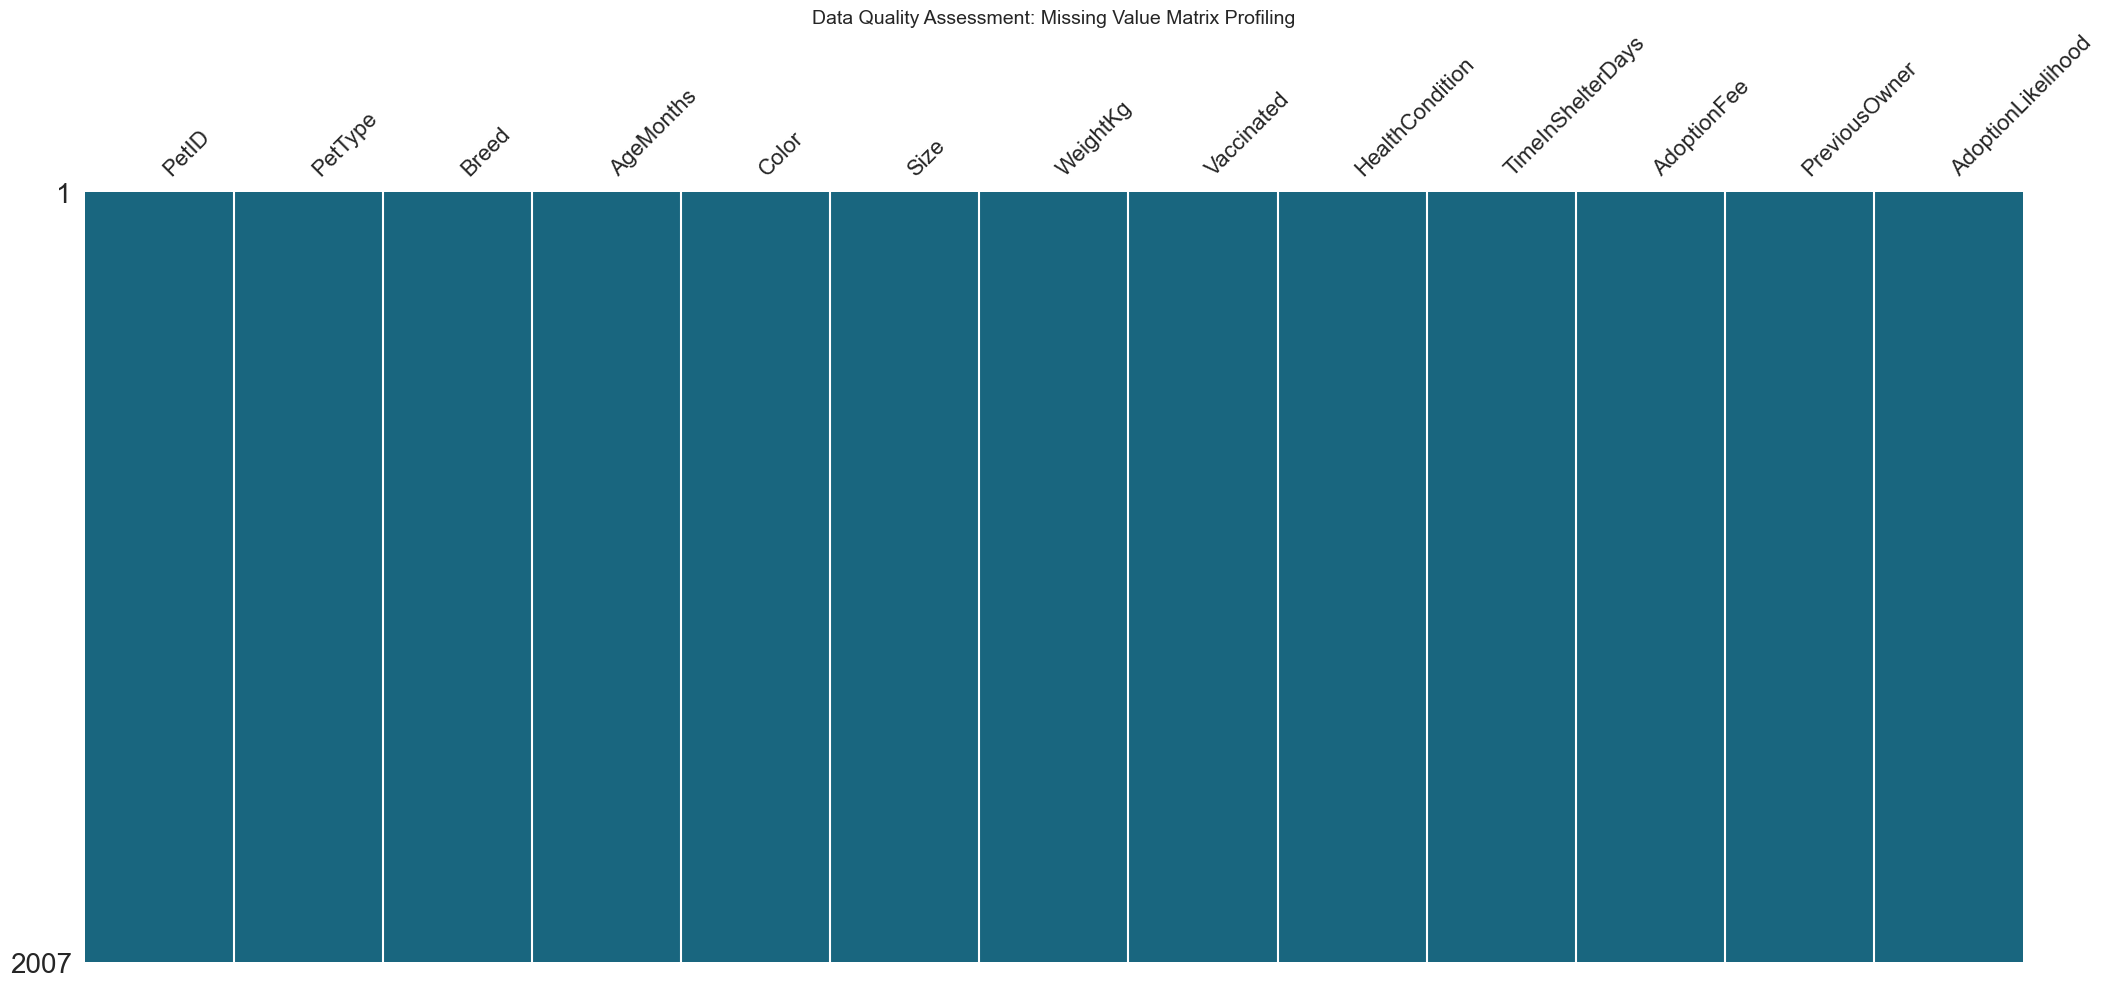

In [25]:
# Visualize any missing data (we know from Section A that there should be no missing values, but included for completeness and confirmation)

plt.figure(figsize=(10, 4))
msno.matrix(adoption_data, sparkline=False, color=(0.1, 0.4, 0.5))
plt.title('Data Quality Assessment: Missing Value Matrix Profiling', fontsize=14)
plt.show()

In [13]:
#Evaluate summary statistics via a transposed table
adoption_data[['AgeMonths', 'WeightKg', 'TimeInShelterDays', 'AdoptionFee']].describe().T

,count,mean,std,min,25%,50%,75%,max
AgeMonths,2007.0,92.279522,52.148363,1.000000,48.000000,94.000000,138.00000,179.000000
WeightKg,2007.0,15.705776,8.327749,1.018198,8.730396,15.925416,22.73718,29.995628
TimeInShelterDays,2007.0,43.974091,25.740253,1.000000,21.000000,45.000000,66.00000,89.000000
AdoptionFee,2007.0,249.142003,142.887040,0.000000,127.000000,242.000000,375.00000,499.000000


In [1]:
#Review for outliers and anomalies across numeric features
plt.figure(figsize=(10, 6))
# We drop PetID as it is just an index and would distort the chart axis scale
adoption_data[['AgeMonths', 'WeightKg', 'TimeInShelterDays', 'AdoptionFee']].boxplot(grid=False, vert=False, fontsize=12)
plt.title('Boxplot Identification of Outliers Across Numerical Features')
plt.show()

NameError: name 'plt' is not defined

In [2]:
# Configure visualization settings
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Target Variable Distribution Analysis
Before diving into individual features, we need to inspect our response variable (`AdoptionLikelihood`) to visually confirm class distributions and establish our baseline probability.

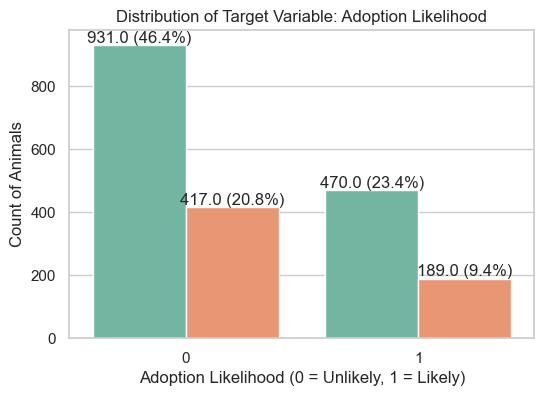

In [30]:
#Target Analysis

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='AdoptionLikelihood', data=adoption_data, palette='Set2', hue=col, legend=False)
plt.title('Distribution of Target Variable: Adoption Likelihood')
plt.xlabel('Adoption Likelihood (0 = Unlikely, 1 = Likely)')
plt.ylabel('Count of Animals')

# Add value labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()} ({p.get_height()/len(adoption_data)*100:.1f}%)', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

## 2. Univariate Analysis: Investigating Every Feature
Systematically visualize the distribution of every independent feature. 

### 2.1 Continuous & Numerical Features
We will plot histograms with Kernel Density Estimates (KDE) to examine distributions, skewness, and spread for: `AgeMonths`, `WeightKg`, `TimeInShelterDays`, and `AdoptionFee`.

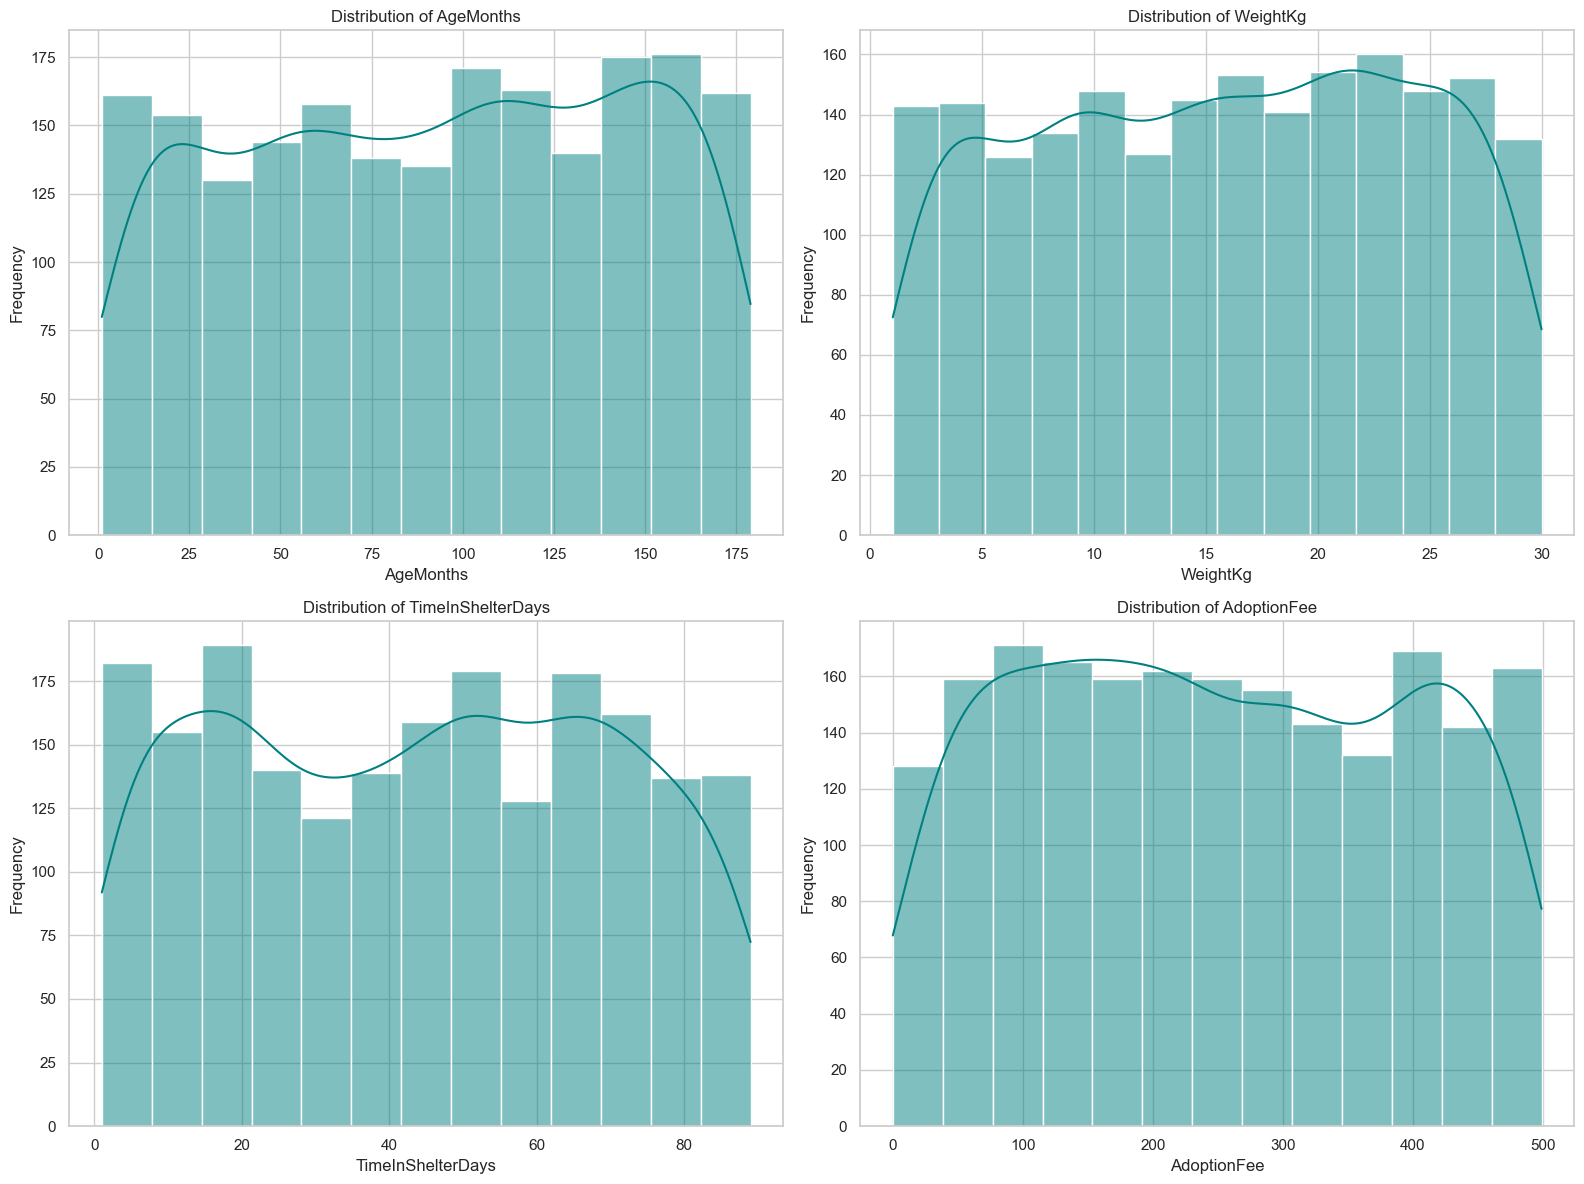

In [6]:
#Numerical Univariate Plots

numerical_cols = ['AgeMonths', 'WeightKg', 'TimeInShelterDays', 'AdoptionFee']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(adoption_data[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [18]:
#Quantifying Shape
print("=== Feature Shape Analysis (Skewness & Kurtosis) ===")
for col in numerical_cols:
    skew_val = adoption_data[col].skew()
    kurt_val = adoption_data[col].kurtosis()
    print(f"{col:20} | Skewness: {skew_val:6.3f} | Kurtosis: {kurt_val:6.3f}")

=== Feature Shape Analysis (Skewness & Kurtosis) ===
AgeMonths            | Skewness: -0.072 | Kurtosis: -1.214
WeightKg             | Skewness: -0.062 | Kurtosis: -1.184
TimeInShelterDays    | Skewness:  0.004 | Kurtosis: -1.211
AdoptionFee          | Skewness:  0.045 | Kurtosis: -1.198


The calculated skewness values sit near 0, verifying that features like AgeMonths and WeightKg follow a relatively flat or balanced distribution uniform process without extreme tail weights that would require a Log transformation transform step.

### 2.2 Categorical & Binary Features
Next, map the count frequencies for all remaining nominal and categorical features: `PetType`, `Breed`, `Color`, `Size`, `Vaccinated`, `HealthCondition`, and `PreviousOwner`.

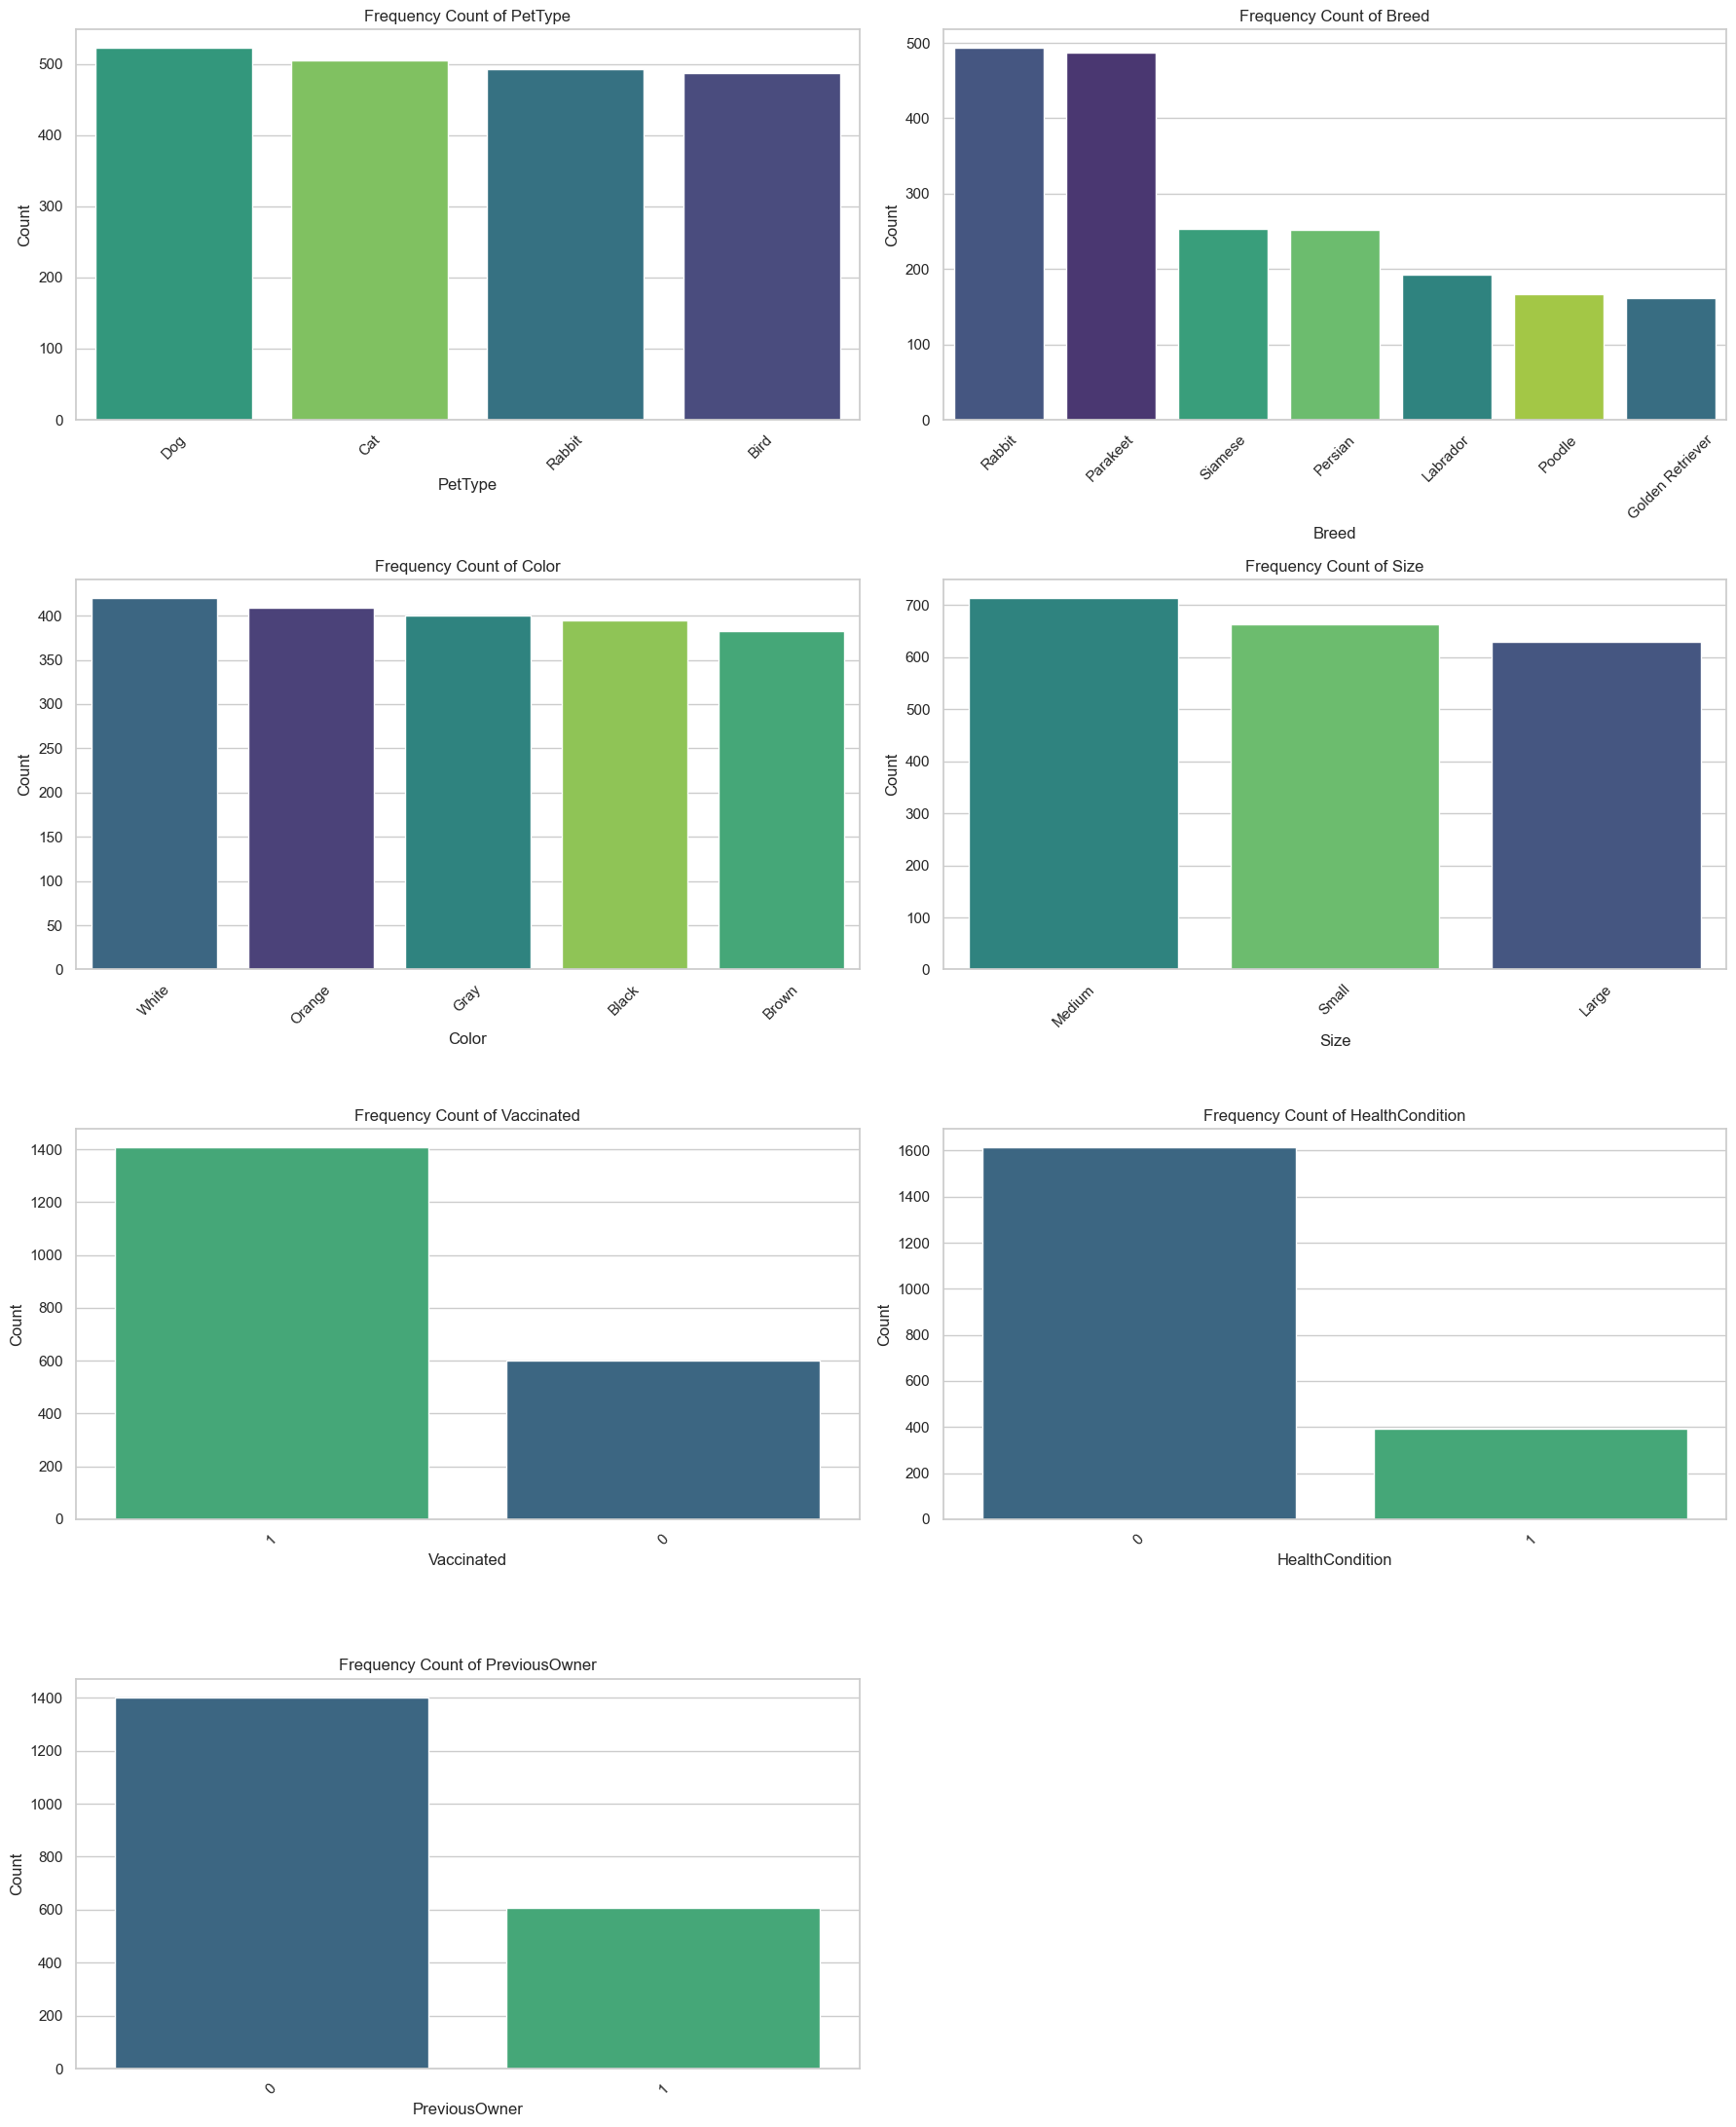

In [31]:
#Categorical univariate plots

categorical_cols = ['PetType', 'Breed', 'Color', 'Size', 'Vaccinated', 'HealthCondition', 'PreviousOwner']

fig, axes = plt.subplots(4, 2, figsize=(18, 22))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=adoption_data, ax=axes[i], palette='viridis', 
                  order=adoption_data[col].value_counts().index, hue=col, legend=False)
    axes[i].set_title(f'Frequency Count of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

# Drop the last empty subplot axis
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

## 3. Bivariate Analysis: Features vs. Target Variable
Now, examine how each feature behaves relative to `AdoptionLikelihood`. This allows us to see which features exhibit distinct patterns between adopted and non-adopted animals.

### 3.1 Continuous Features vs. Target (Box Plots)

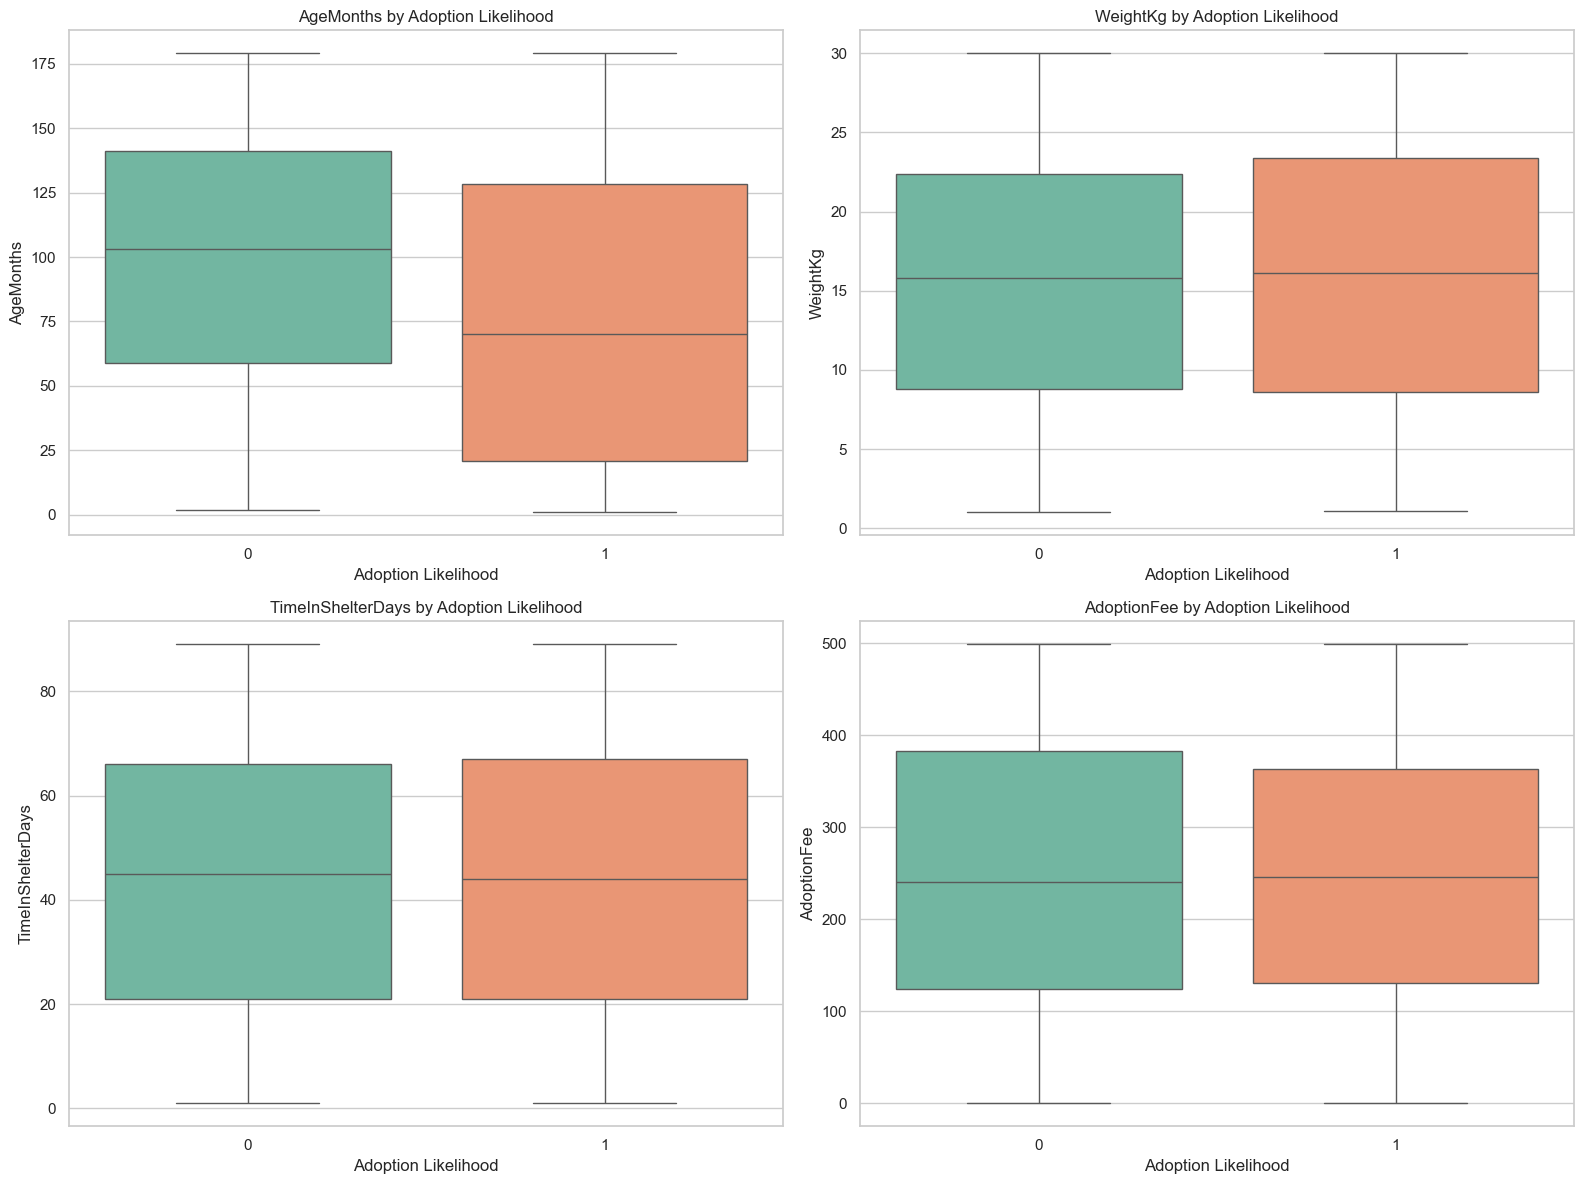

In [35]:
#Bivariate numerical plots

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x='AdoptionLikelihood', y=col, data=adoption_data, ax=axes[i], palette='Set2', hue='AdoptionLikelihood', legend=False)
    axes[i].set_title(f'{col} by Adoption Likelihood')
    axes[i].set_xlabel('Adoption Likelihood')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

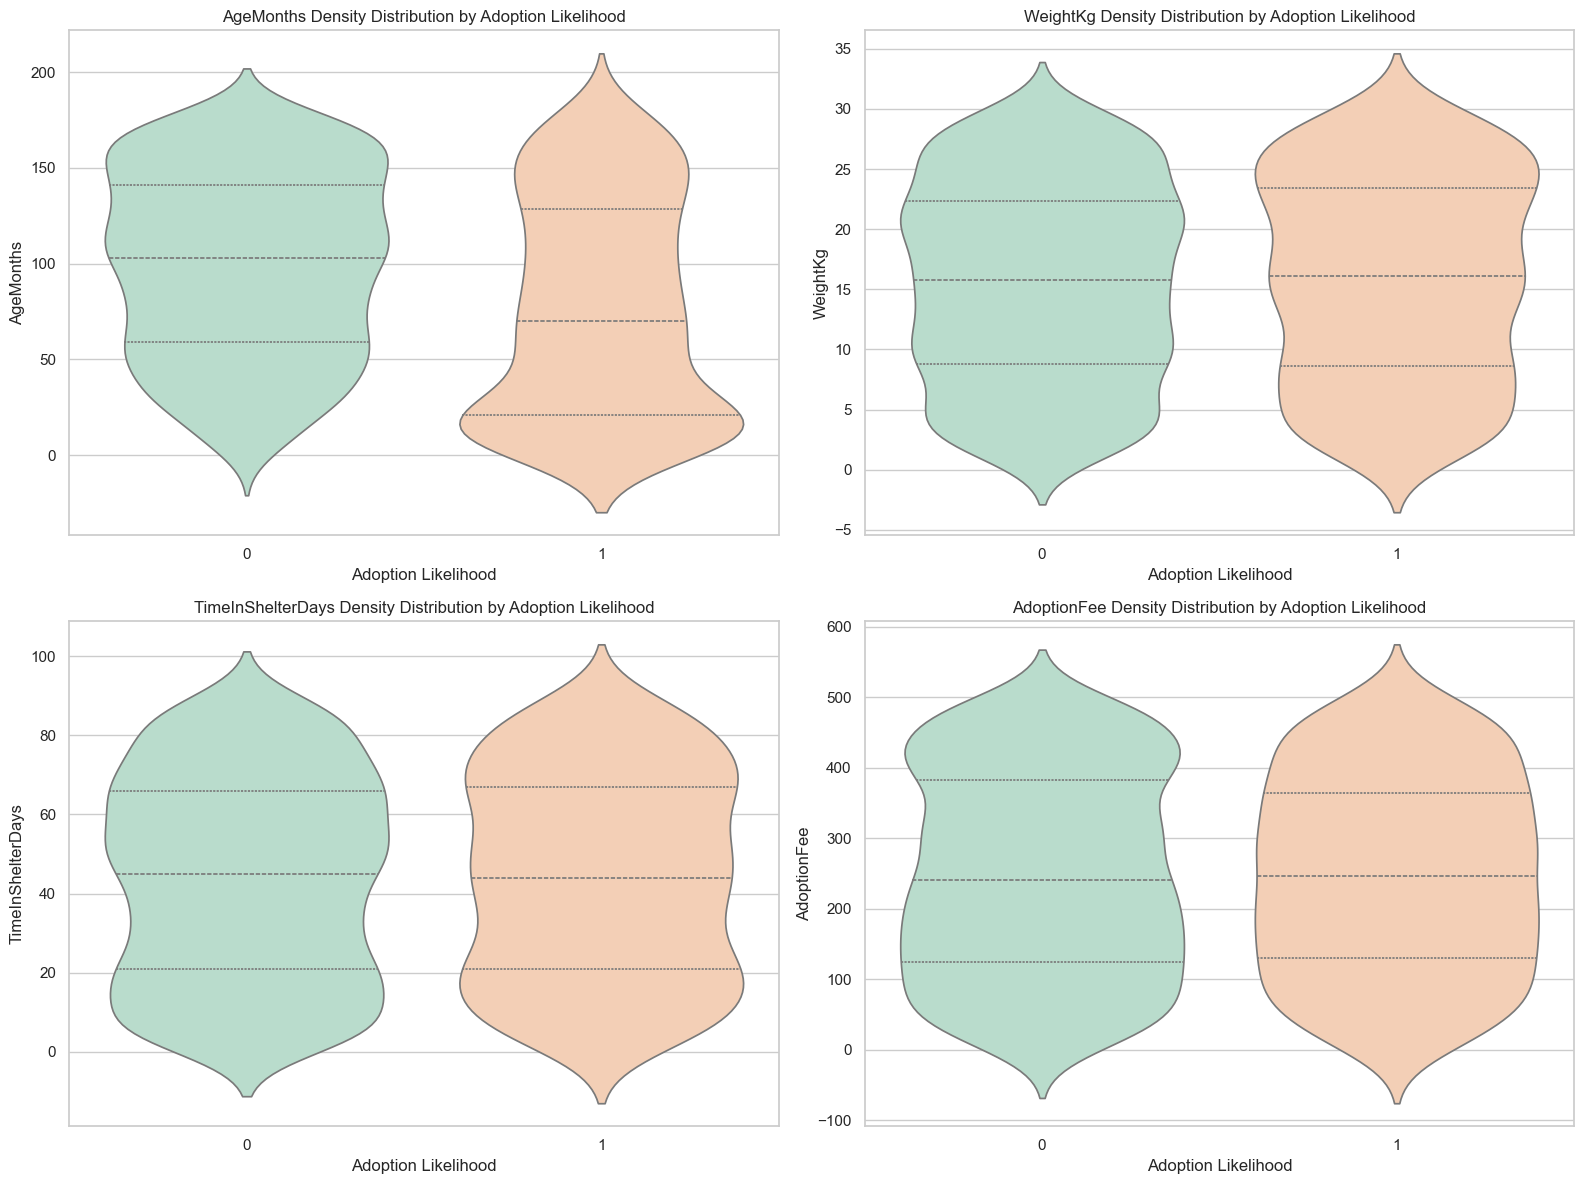

In [36]:
# Categorical x Continuous via Violin Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.violinplot(x='AdoptionLikelihood', y=col, data=adoption_data, ax=axes[i], 
                   palette='Pastel2', inner='quartile', hue='AdoptionLikelihood', legend=False)
    axes[i].set_title(f'{col} Density Distribution by Adoption Likelihood')
    axes[i].set_xlabel('Adoption Likelihood')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

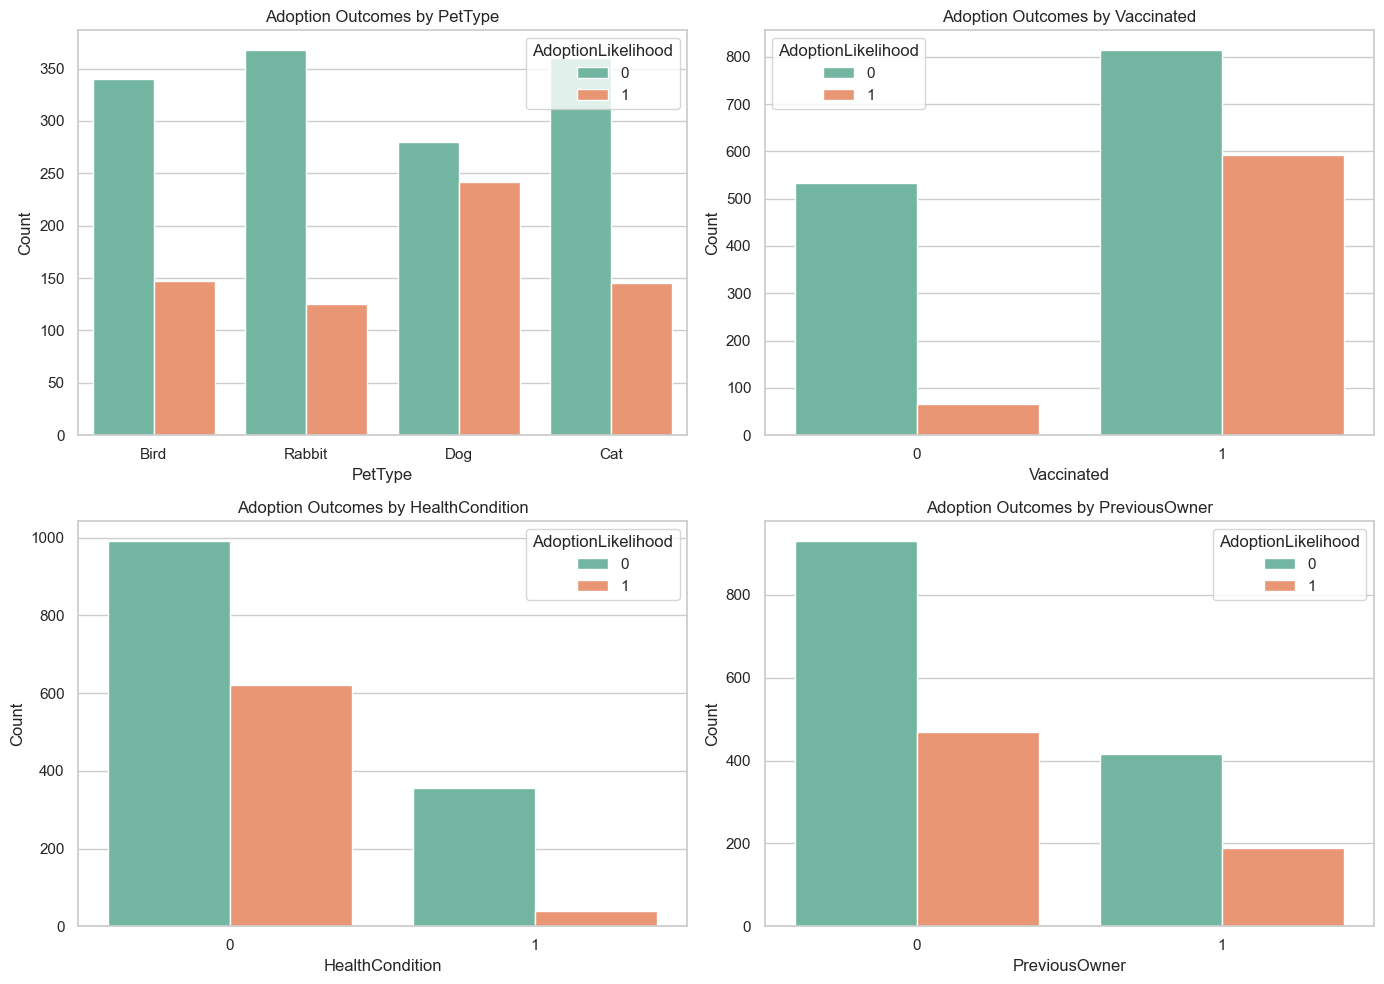

In [44]:
# Proportional breakdown of categorical/binary metrics by adoption outcome
categorical_analysis_cols = ['PetType', 'Vaccinated', 'HealthCondition', 'PreviousOwner']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_analysis_cols):
    sns.countplot(x=col, hue='AdoptionLikelihood', data=adoption_data, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Adoption Outcomes by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [45]:
for col in categorical_analysis_cols:
    print(f"--- Proportion breakdown for {col} ---")
    display(pd.crosstab(adoption_data[col], adoption_data['AdoptionLikelihood'], normalize='index'))
    print("\n")

--- Proportion breakdown for PetType ---


AdoptionLikelihood,0,1
PetType,,
Bird,0.698152,0.301848
Cat,0.712871,0.287129
Dog,0.536398,0.463602
Rabbit,0.746450,0.253550




--- Proportion breakdown for Vaccinated ---


AdoptionLikelihood,0,1
Vaccinated,,
0,0.888333,0.111667
1,0.579247,0.420753




--- Proportion breakdown for HealthCondition ---


AdoptionLikelihood,0,1
HealthCondition,,
0,0.615003,0.384997
1,0.903553,0.096447




--- Proportion breakdown for PreviousOwner ---


AdoptionLikelihood,0,1
PreviousOwner,,
0,0.664525,0.335475
1,0.688119,0.311881


### 3.2 Categorical Subgroups vs. Target (Adoption Rates)
Look at the percentage of adoptions across different subgroups to identify significant variations.

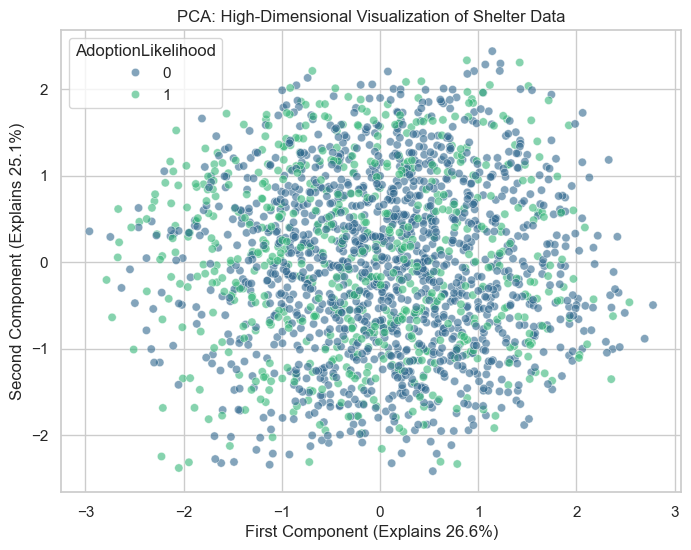

In [29]:
#PCA Visualization

# Select continuous numeric features for PCA
numeric_features = ['AgeMonths', 'WeightKg', 'TimeInShelterDays', 'AdoptionFee']
x = adoption_data[numeric_features]

# Scale the features (as done in the guided capstone)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Apply PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(x_scaled)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])
pca_df['AdoptionLikelihood'] = adoption_data['AdoptionLikelihood'].values

# Plot the PCA space colored by target variable
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='AdoptionLikelihood', data=pca_df, alpha=0.6, palette='viridis')
plt.title('PCA: High-Dimensional Visualization of Shelter Data')
plt.xlabel(f'First Component (Explains {pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Second Component (Explains {pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.show()

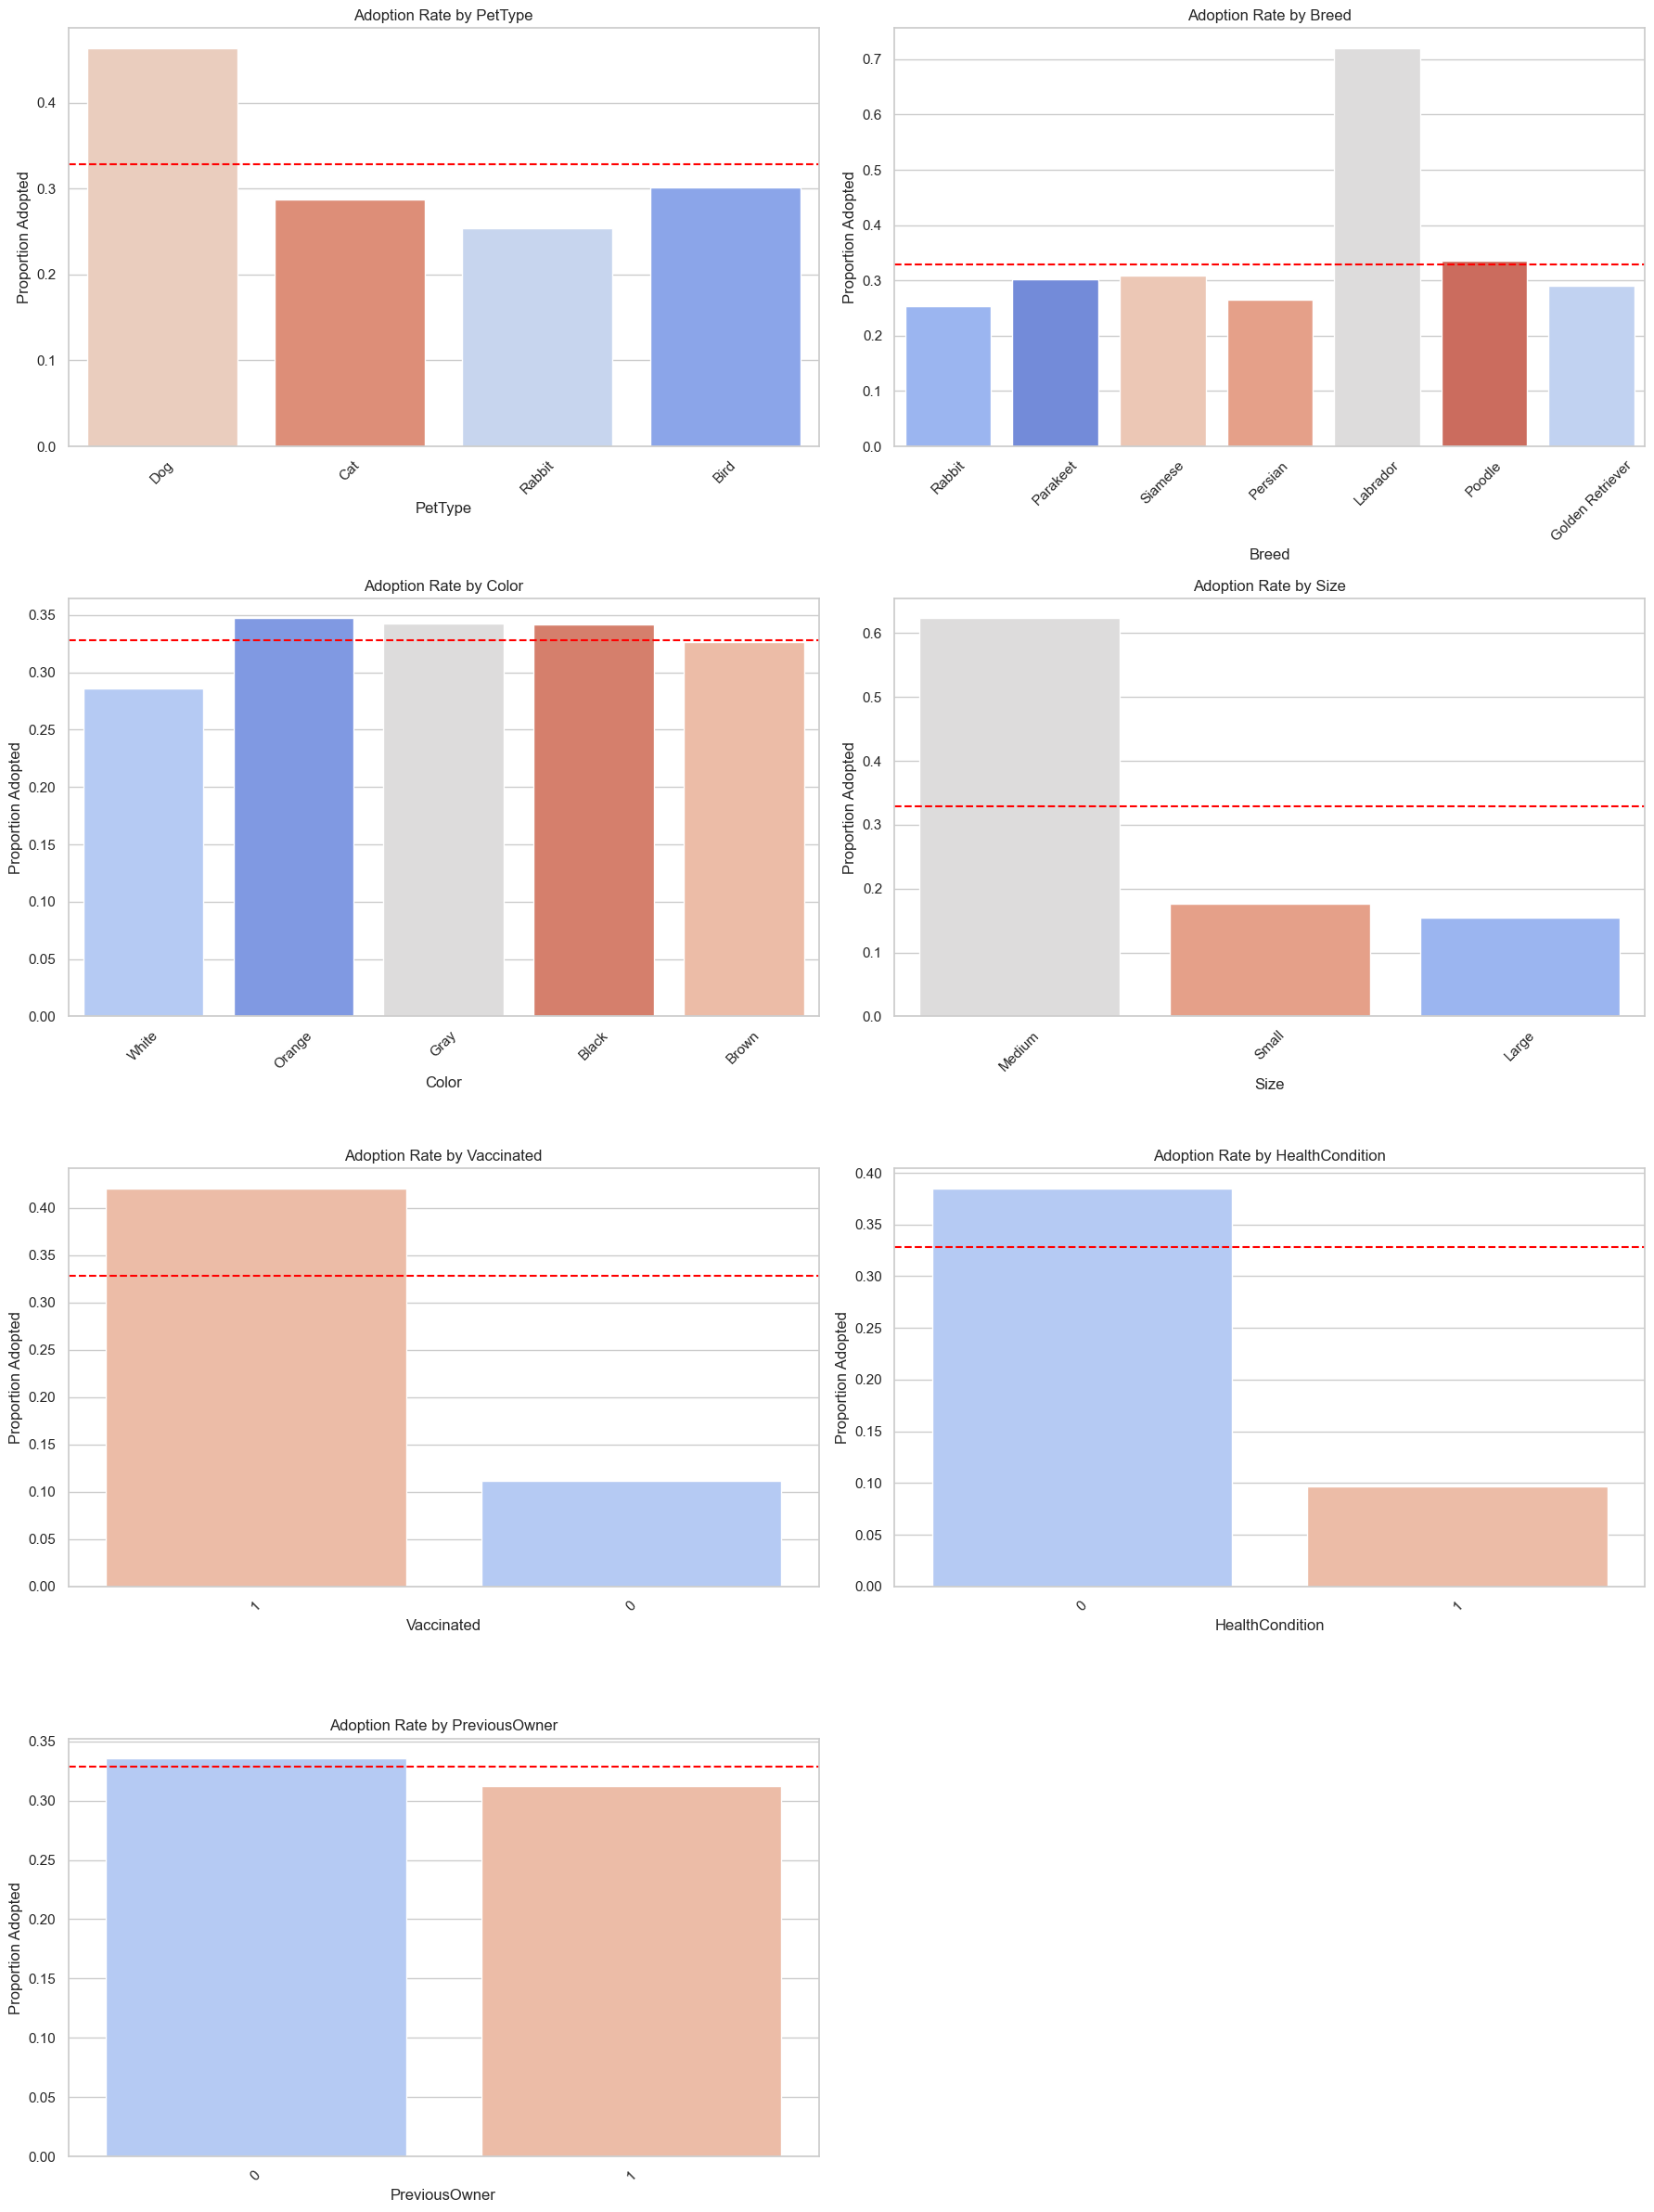

In [37]:
#Bivariate categorical plots

fig, axes = plt.subplots(4, 2, figsize=(18, 24))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Calculate adoption rate per subgroup
    sns.barplot(x=col, y='AdoptionLikelihood', data=adoption_data, ax=axes[i], 
                palette='coolwarm', errorbar=None, order=adoption_data[col].value_counts().index, hue=col, legend=False)
    axes[i].set_title(f'Adoption Rate by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Proportion Adopted')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].axhline(adoption_data['AdoptionLikelihood'].mean(), color='red', linestyle='--', label='Baseline Avg')

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

## 4. Correlation Matrices & Statistical Strengths
Evaluate the Pearson correlation coefficients among numerical variables to isolate linear dependencies and screen for multi-collinearity.

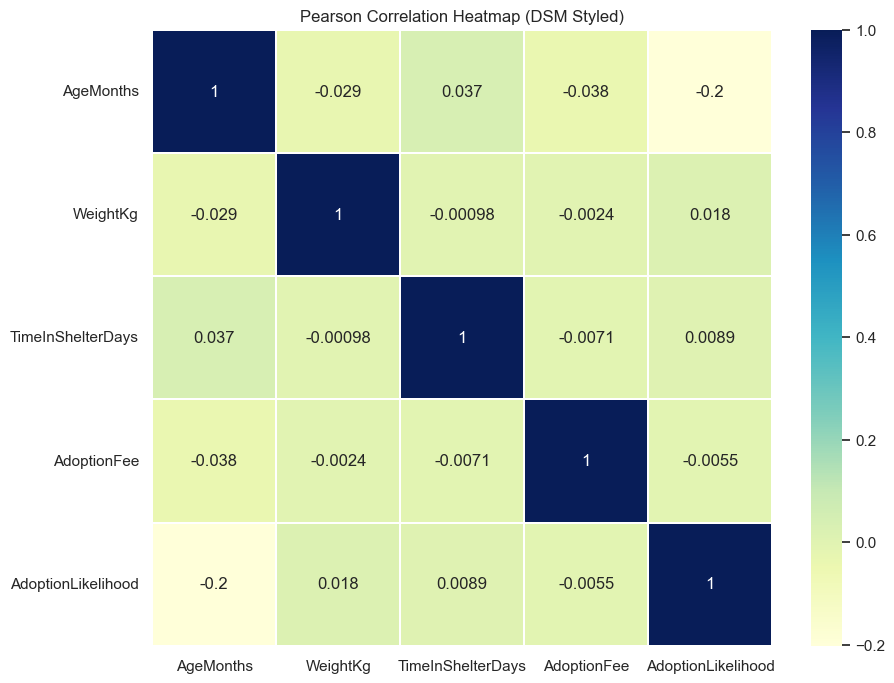

In [17]:
#Correlation heatmap

# Create the correlation matrix heat map
plt.figure(figsize=(10, 8))
corr_matrix = adoption_data[['AgeMonths', 'WeightKg', 'TimeInShelterDays', 'AdoptionFee', 'AdoptionLikelihood']].corr()
sns.heatmap(corr_matrix, linewidths=.1, cmap="YlGnBu", annot=True)
plt.yticks(rotation=0)
plt.title('Pearson Correlation Heatmap (DSM Styled)')
plt.show()

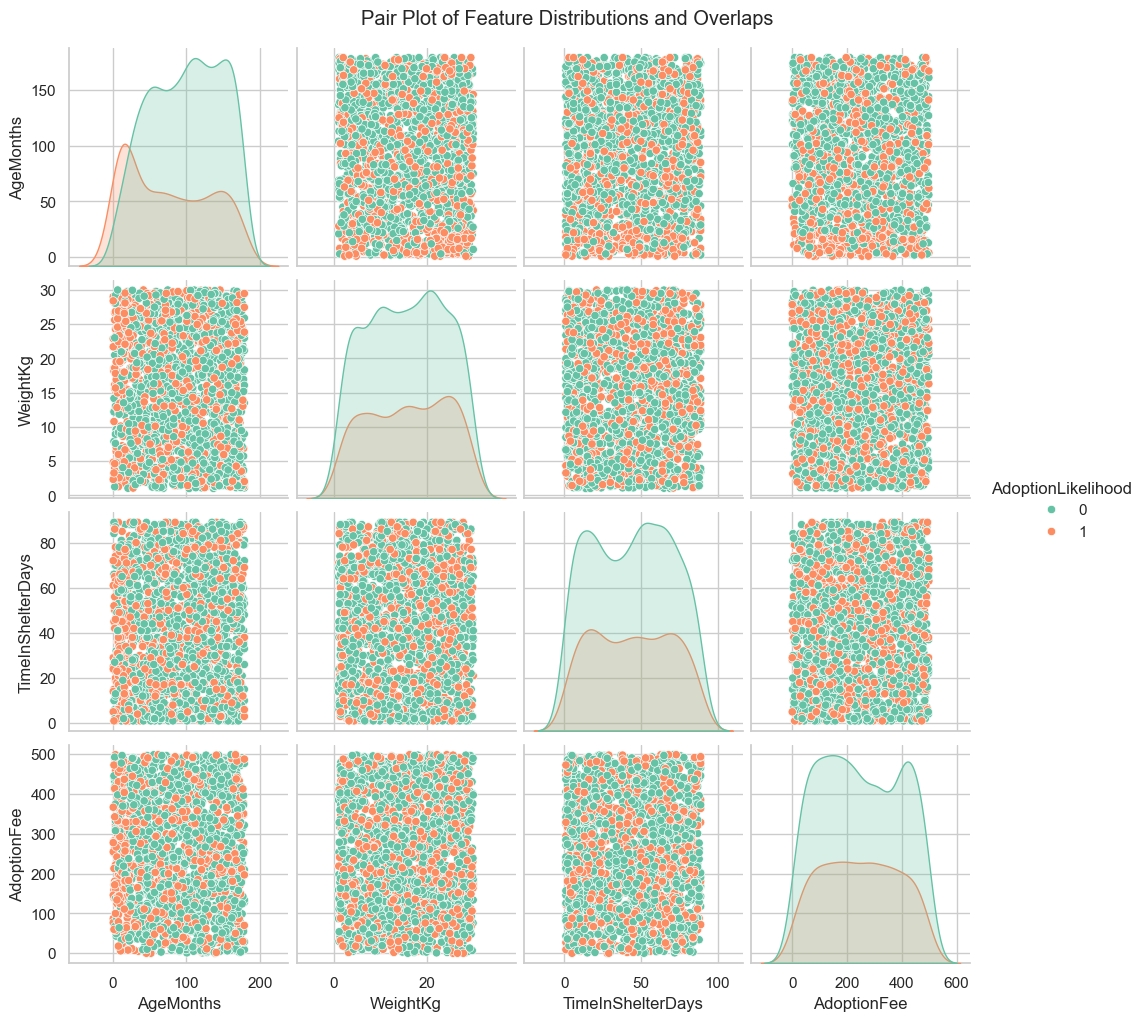

In [16]:
#Investigate multi-variable relationships via pair plots
# Include target variable as the 'hue' to see class separation visually
numeric_cols_with_target = ['AgeMonths', 'WeightKg', 'TimeInShelterDays', 'AdoptionFee', 'AdoptionLikelihood']
g = sns.pairplot(adoption_data[numeric_cols_with_target], hue='AdoptionLikelihood', palette='Set2')
plt.suptitle('Pair Plot of Feature Distributions and Overlaps', y=1.02)
plt.show()

## 5. Inferential Statistics & Hypothesis Testing
Conduct formal testing for statistical relationships. Based on the bivariate plots, establish a formal hypothesis regarding how a critical feature impacts adoptions.

### Hypothesis Test: Medical Status vs. Adoption Likelihood
* **Null Hypothesis ($H_0$):** There is no association between an animal's `HealthCondition` (0 vs 1) and its `AdoptionLikelihood`. They are statistically independent.
* **Alternative Hypothesis ($H_1$):** There is a statistically significant association between `HealthCondition` and `AdoptionLikelihood`.

Because both features are categorical/binary, a **Chi-Square Test of Independence** is the most appropriate statistical method.

In [12]:
#Chi square test

# Construct the contingency table
contingency_table = pd.crosstab(adoption_data['HealthCondition'], adoption_data['AdoptionLikelihood'])
print("--- Contingency Table ---")
print(contingency_table)

# Run Chi-Square Test
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_val:.4e}")
print(f"Degrees of Freedom: {dof}")

alpha = 0.05
if p_val < alpha:
    print("\nResult: Reject the Null Hypothesis ($H_0$). The association is statistically significant.")
else:
    print("\nResult: Fail to reject the Null Hypothesis ($H_0$). No statistically significant association found.")

--- Contingency Table ---
AdoptionLikelihood    0    1
HealthCondition             
0                   992  621
1                   356   38

Chi-Square Statistic: 118.2440
P-value: 1.5332e-27
Degrees of Freedom: 1

Result: Reject the Null Hypothesis ($H_0$). The association is statistically significant.


In [22]:
# Verify Category Threshold constraints
print("=== Category Simplification & Cardinality Verification ===")
for col in categorical_cols:
    num_unique = adoption_data[col].nunique()
    status = "PASSED (Under 8-10 threshold)" if num_unique <= 10 else "WARNING (Requires Aggregation)"
    print(f"Feature: {col:18} | Unique Categories: {num_unique:2} | Status: {status}")

=== Category Simplification & Cardinality Verification ===
Feature: PetType            | Unique Categories:  4 | Status: PASSED (Under 8-10 threshold)
Feature: Breed              | Unique Categories:  7 | Status: PASSED (Under 8-10 threshold)
Feature: Color              | Unique Categories:  5 | Status: PASSED (Under 8-10 threshold)
Feature: Size               | Unique Categories:  3 | Status: PASSED (Under 8-10 threshold)
Feature: Vaccinated         | Unique Categories:  2 | Status: PASSED (Under 8-10 threshold)
Feature: HealthCondition    | Unique Categories:  2 | Status: PASSED (Under 8-10 threshold)
Feature: PreviousOwner      | Unique Categories:  2 | Status: PASSED (Under 8-10 threshold)


All categorical feature dimensions (such as Breed and Color) contain fewer than 8-10 unique labels, validating that higher-level category consolidation is unnecessary for this array schema.

## 6. Initial Feature Selection & Engineering Strategy

Based on the numerical distributions and bivariate relationships established during this EDA session, we can make data-supported decisions to guide the upcoming preprocessing phase:

1.  **Multi-Species Complexity:** The `WeightKg` field spans from ~1kg to ~30kg across birds, rabbits, cats, and dogs. Leaving this raw could confuse a linear model. We should engineer a `Weight_Relative_To_Species` feature or standardize within species groups.
2.  **Target Balancing:** With a baseline adoption rate around ~33%, standard stratifying during our train-test split will be vital to ensure stable model evaluations without requiring synthetic oversampling like SMOTE.
3.  **Encoding Strategy:** High-cardinality categorical variables like `Breed` (7 unique categories) and `PetType` (4 categories) will be transformed via **One-Hot Encoding**. Ordinal categorization can be safely ruled out since there is no inherent ranking.
4.  **Feature Exclusion:** `PetID` provides unique index signaling without any underlying variance capacity. It will be dropped prior to splitting training arrays.

In [28]:
# Example: Categorize animals into life stages based on AgeMonths
def assign_life_stage(months):
    if months <= 6: return 'Infant/Puppy/Kitten'
    elif months <= 24: return 'Young Adult'
    elif months <= 84: return 'Adult'
    else: return 'Senior'

adoption_data['LifeStage'] = adoption_data['AgeMonths'].apply(assign_life_stage)

### Future Pre-processing Adjustments
- **Multicollinearity Check:** Our Pearson correlation heatmap shows whether our independent numerical traits are heavily correlated with each other. Since our features show low linear dependency, standard linear classifiers remain viable without requiring an upfront dimension reduction step like **Principal Components Analysis (PCA)** (shown above for completeness, regardless).
- **Feature Augmentation:** During the upcoming feature engineering phase, we can evaluate creating feature groups (such as binning continuous data or exploring K-Means clustering to create sub-population clusters as unique model inputs).

In [39]:
# Save the clean, modified data for the next step (Pre-processing/Modeling)

# Define the path and save to a new CSV file
datapath = 'C:\\Users\\alyss\\OneDrive\\Springboard Data Science Bootcamp\\Capstone 2\\Springboard Capstone 2 Adoption Prediction Model\\data'
if not os.path.exists(datapath):
    os.makedirs(datapath)

adoption_data.to_csv(os.path.join(datapath, 'pet_adoption_data_clean_eda.csv'), index=False)